# Math for Machine Learning — Linear Algebra Week 2

## Solving Systems of Equations, Row Reduction, RREF, and Rank

This notebook converts the Week 2 PDF slide concepts into runnable Jupyter Notebook code.

Topics:
- Solving non-singular systems
- Singular redundant and contradictory systems
- Matrix row reduction
- Row operations that preserve singularity
- Row echelon form and reduced row echelon form
- Rank of a matrix
- Machine learning connection


In [1]:
import numpy as np
import matplotlib.pyplot as plt

try:
    import sympy as sp
    sympy_available = True
except ImportError:
    sympy_available = False
    print("SymPy is not installed. Run this in a notebook cell: %pip install sympy")


## 1. Solving a Non-Singular 2×2 System

From the slides:

\[
a+b=10
\]

\[
a+2b=12
\]

This system has a unique solution.


In [2]:
A = np.array([[1, 1],
              [1, 2]], dtype=float)

b = np.array([10, 12], dtype=float)

solution = np.linalg.solve(A, b)

print("a =", solution[0])
print("b =", solution[1])


a = 8.0
b = 2.0


## 2. Determinant Check

A square matrix is non-singular if its determinant is not zero.


In [3]:
det_A = np.linalg.det(A)

print("Determinant:", det_A)

if abs(det_A) > 1e-10:
    print("The matrix is non-singular.")
else:
    print("The matrix is singular.")


Determinant: 1.0
The matrix is non-singular.


## 3. A Harder 2×2 Example

\[
5a+b=17
\]

\[
4a-3b=6
\]

Expected solution:

\[
a=3, \quad b=2
\]


In [4]:
A = np.array([[5, 1],
              [4, -3]], dtype=float)

b = np.array([17, 6], dtype=float)

solution = np.linalg.solve(A, b)

print("a =", solution[0])
print("b =", solution[1])


a = 3.0
b = 2.0000000000000004


## 4. Row Reduction with SymPy

The augmented matrix is:

\[
\left[
\begin{array}{cc|c}
5 & 1 & 17 \\
4 & -3 & 6
\end{array}
\right]
\]


In [5]:
if sympy_available:
    augmented = sp.Matrix([
        [5, 1, 17],
        [4, -3, 6]
    ])

    print("Augmented matrix:")
    display(augmented)

    rref_matrix, pivot_columns = augmented.rref()

    print("Reduced row echelon form:")
    display(rref_matrix)

    print("Pivot columns:", pivot_columns)
else:
    print("Install SymPy first: %pip install sympy")


Augmented matrix:


Matrix([
[5,  1, 17],
[4, -3,  6]])

Reduced row echelon form:


Matrix([
[1, 0, 3],
[0, 1, 2]])

Pivot columns: (0, 1)


## 5. Singular Redundant System

\[
a+b=10
\]

\[
2a+2b=20
\]

The second equation is twice the first equation. The system has infinitely many solutions.


In [6]:
A = np.array([[1, 1],
              [2, 2]], dtype=float)

b = np.array([10, 20], dtype=float)

print("Coefficient matrix:")
print(A)
print("Determinant:", np.linalg.det(A))
print("Rank of A:", np.linalg.matrix_rank(A))

try:
    solution = np.linalg.solve(A, b)
    print("Solution:", solution)
except np.linalg.LinAlgError as e:
    print("Cannot solve uniquely because the matrix is singular.")
    print("Reason:", e)


Coefficient matrix:
[[1. 1.]
 [2. 2.]]
Determinant: 0.0
Rank of A: 1
Cannot solve uniquely because the matrix is singular.
Reason: Singular matrix


### General Solution

Since:

\[
a+b=10
\]

Let:

\[
b=t
\]

Then:

\[
a=10-t
\]

So the solutions are:

\[
(a,b)=(10-t,t)
\]


In [7]:
t_values = [-2, 0, 2, 5, 10, 15]

for t in t_values:
    a = 10 - t
    b_value = t
    print(f"a = {a}, b = {b_value}")


a = 12, b = -2
a = 10, b = 0
a = 8, b = 2
a = 5, b = 5
a = 0, b = 10
a = -5, b = 15


## 6. Singular Contradictory System

\[
a+b=10
\]

\[
2a+2b=24
\]

The second equation becomes:

\[
a+b=12
\]

So the system has no solution.


In [8]:
A = np.array([[1, 1],
              [2, 2]], dtype=float)

b = np.array([10, 24], dtype=float)

augmented = np.column_stack([A, b])

print("Rank(A):", np.linalg.matrix_rank(A))
print("Rank([A|b]):", np.linalg.matrix_rank(augmented))

if np.linalg.matrix_rank(A) < np.linalg.matrix_rank(augmented):
    print("No solution: the system is inconsistent.")
else:
    print("The system may have solutions.")


Rank(A): 1
Rank([A|b]): 2
No solution: the system is inconsistent.


## 7. Solving a 3×3 System

\[
a+b+2c=12
\]

\[
3a-3b-c=3
\]

\[
2a-b+6c=24
\]

Expected solution:

\[
a=4,\quad b=2,\quad c=3
\]


In [9]:
A = np.array([[1, 1, 2],
              [3, -3, -1],
              [2, -1, 6]], dtype=float)

b = np.array([12, 3, 24], dtype=float)

solution = np.linalg.solve(A, b)

print("a =", solution[0])
print("b =", solution[1])
print("c =", solution[2])


a = 4.0
b = 2.0
c = 3.0


## 8. RREF for the 3×3 System


In [10]:
if sympy_available:
    augmented = sp.Matrix([
        [1, 1, 2, 12],
        [3, -3, -1, 3],
        [2, -1, 6, 24]
    ])

    print("Augmented matrix:")
    display(augmented)

    rref_matrix, pivot_columns = augmented.rref()

    print("Reduced row echelon form:")
    display(rref_matrix)

    print("Pivot columns:", pivot_columns)
else:
    print("Install SymPy first: %pip install sympy")


Augmented matrix:


Matrix([
[1,  1,  2, 12],
[3, -3, -1,  3],
[2, -1,  6, 24]])

Reduced row echelon form:


Matrix([
[1, 0, 0, 4],
[0, 1, 0, 2],
[0, 0, 1, 3]])

Pivot columns: (0, 1, 2)


## 9. Row Operations That Preserve Singularity

The slides discuss three row operations:

1. Swapping rows
2. Multiplying a row by a nonzero scalar
3. Adding one row to another row

These operations preserve whether a matrix is singular or non-singular.


In [11]:
A = np.array([[5, 1],
              [4, 3]], dtype=float)

print("Original matrix:")
print(A)
print("Original determinant:", np.linalg.det(A))

A_swapped = A[[1, 0], :]
print("\nAfter swapping rows:")
print(A_swapped)
print("New determinant:", np.linalg.det(A_swapped))

A_scaled = A.copy()
A_scaled[0] = 10 * A_scaled[0]
print("\nAfter multiplying row 1 by 10:")
print(A_scaled)
print("New determinant:", np.linalg.det(A_scaled))

A_added = A.copy()
A_added[0] = A_added[0] + A_added[1]
print("\nAfter adding row 2 to row 1:")
print(A_added)
print("New determinant:", np.linalg.det(A_added))


Original matrix:
[[5. 1.]
 [4. 3.]]
Original determinant: 11.000000000000002

After swapping rows:
[[4. 3.]
 [5. 1.]]
New determinant: -11.000000000000002

After multiplying row 1 by 10:
[[50. 10.]
 [ 4.  3.]]
New determinant: 110.00000000000004

After adding row 2 to row 1:
[[9. 4.]
 [4. 3.]]
New determinant: 11.000000000000002


## 10. Row Echelon Form and RREF

A matrix is in row echelon form when:

- Zero rows are at the bottom.
- Each nonzero row has a pivot.
- Each pivot is to the right of the pivot above it.

A matrix is in reduced row echelon form when:

- It is already in row echelon form.
- Each pivot is 1.
- Entries above and below each pivot are 0.


In [12]:
if sympy_available:
    A = sp.Matrix([
        [5, 1],
        [4, -3]
    ])

    print("Original matrix:")
    display(A)

    rref_A, pivots = A.rref()

    print("Reduced row echelon form:")
    display(rref_A)

    print("Pivot columns:", pivots)
else:
    print("Install SymPy first: %pip install sympy")


Original matrix:


Matrix([
[5,  1],
[4, -3]])

Reduced row echelon form:


Matrix([
[1, 0],
[0, 1]])

Pivot columns: (0, 1)


## 11. Rank of a Matrix

The rank of a matrix is the number of independent pieces of information in the matrix.

It is also the number of pivots in row echelon form or reduced row echelon form.


In [13]:
matrices = {
    "Matrix 1": np.array([[1, 1], [1, 2]], dtype=float),
    "Matrix 2": np.array([[1, 1], [2, 2]], dtype=float),
    "Matrix 3": np.array([[0, 0], [0, 0]], dtype=float),
}

for name, M in matrices.items():
    print(name)
    print(M)
    print("Rank:", np.linalg.matrix_rank(M))
    print("Determinant:", np.linalg.det(M))
    print("-" * 30)


Matrix 1
[[1. 1.]
 [1. 2.]]
Rank: 2
Determinant: 1.0
------------------------------
Matrix 2
[[1. 1.]
 [2. 2.]]
Rank: 1
Determinant: 0.0
------------------------------
Matrix 3
[[0. 0.]
 [0. 0.]]
Rank: 0
Determinant: 0.0
------------------------------


## 12. Rank Examples for 3×3 Matrices


In [14]:
matrices_3x3 = {
    "Matrix 1": np.array([[1, 1, 1], [1, 2, 1], [1, 1, 2]], dtype=float),
    "Matrix 2": np.array([[1, 1, 1], [1, 1, 2], [1, 1, 3]], dtype=float),
    "Matrix 3": np.array([[1, 1, 1], [2, 2, 2], [3, 3, 3]], dtype=float),
    "Matrix 4": np.array([[0, 0, 0], [0, 0, 0], [0, 0, 0]], dtype=float),
}

for name, M in matrices_3x3.items():
    print(name)
    print(M)
    print("Rank:", np.linalg.matrix_rank(M))
    print("Determinant:", np.linalg.det(M))
    if abs(np.linalg.det(M)) > 1e-10:
        print("Non-singular")
    else:
        print("Singular")
    print("-" * 40)


Matrix 1
[[1. 1. 1.]
 [1. 2. 1.]
 [1. 1. 2.]]
Rank: 3
Determinant: 1.0
Non-singular
----------------------------------------
Matrix 2
[[1. 1. 1.]
 [1. 1. 2.]
 [1. 1. 3.]]
Rank: 2
Determinant: 0.0
Singular
----------------------------------------
Matrix 3
[[1. 1. 1.]
 [2. 2. 2.]
 [3. 3. 3.]]
Rank: 1
Determinant: 0.0
Singular
----------------------------------------
Matrix 4
[[0. 0. 0.]
 [0. 0. 0.]
 [0. 0. 0.]]
Rank: 0
Determinant: 0.0
Singular
----------------------------------------


## 13. RREF for the 3×3 Rank Examples


In [15]:
if sympy_available:
    for name, M in matrices_3x3.items():
        print(name)
        S = sp.Matrix(M.astype(int))
        display(S)

        rref_M, pivots = S.rref()

        print("RREF:")
        display(rref_M)
        print("Pivot columns:", pivots)
        print("Rank:", len(pivots))
        print("-" * 40)
else:
    print("Install SymPy first: %pip install sympy")


Matrix 1


Matrix([
[1, 1, 1],
[1, 2, 1],
[1, 1, 2]])

RREF:


Matrix([
[1, 0, 0],
[0, 1, 0],
[0, 0, 1]])

Pivot columns: (0, 1, 2)
Rank: 3
----------------------------------------
Matrix 2


...

Pivot columns: (0,)
Rank: 1
----------------------------------------
Matrix 4


Matrix([
[0, 0, 0],
[0, 0, 0],
[0, 0, 0]])

RREF:


Matrix([
[0, 0, 0],
[0, 0, 0],
[0, 0, 0]])

Pivot columns: ()
Rank: 0
----------------------------------------


## 14. Visualizing a Unique Solution

\[
a+b=10
\]

\[
a+2b=12
\]


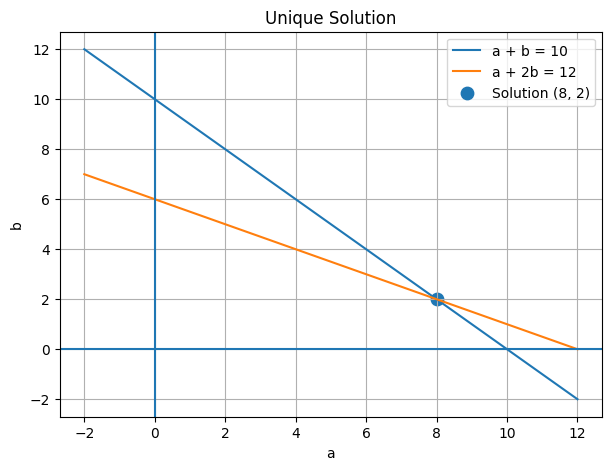

In [16]:
a_values = np.linspace(-2, 12, 200)

b1 = 10 - a_values
b2 = (12 - a_values) / 2

plt.figure(figsize=(7, 5))
plt.plot(a_values, b1, label="a + b = 10")
plt.plot(a_values, b2, label="a + 2b = 12")
plt.scatter([8], [2], s=80, label="Solution (8, 2)")
plt.axhline(0)
plt.axvline(0)
plt.xlabel("a")
plt.ylabel("b")
plt.title("Unique Solution")
plt.legend()
plt.grid(True)
plt.show()


## 15. Visualizing Infinite Solutions

\[
a+b=10
\]

\[
2a+2b=20
\]


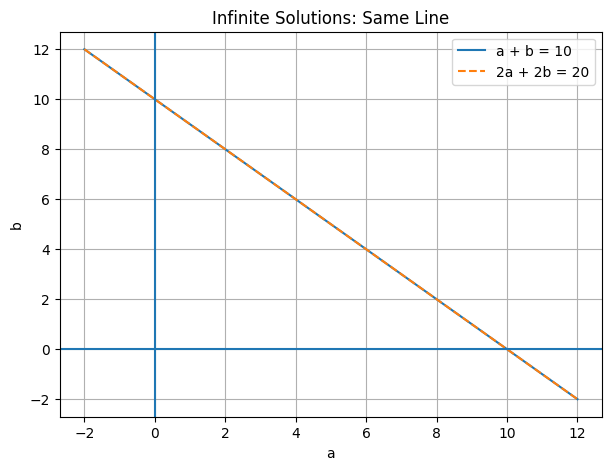

In [17]:
a_values = np.linspace(-2, 12, 200)

b1 = 10 - a_values
b2 = (20 - 2*a_values) / 2

plt.figure(figsize=(7, 5))
plt.plot(a_values, b1, label="a + b = 10")
plt.plot(a_values, b2, "--", label="2a + 2b = 20")
plt.axhline(0)
plt.axvline(0)
plt.xlabel("a")
plt.ylabel("b")
plt.title("Infinite Solutions: Same Line")
plt.legend()
plt.grid(True)
plt.show()


## 16. Visualizing No Solution

\[
a+b=10
\]

\[
2a+2b=24
\]


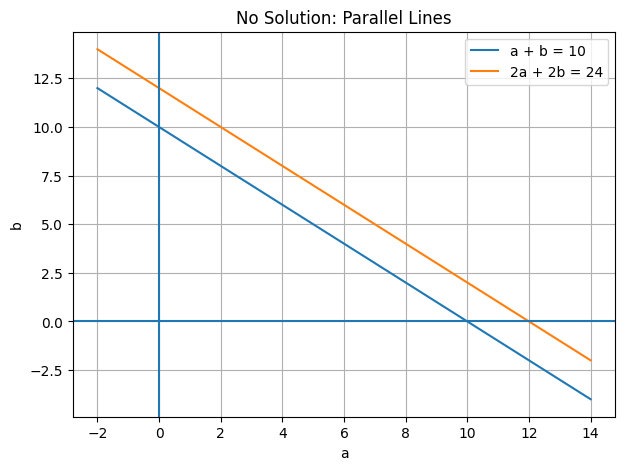

In [18]:
a_values = np.linspace(-2, 14, 200)

b1 = 10 - a_values
b2 = 12 - a_values

plt.figure(figsize=(7, 5))
plt.plot(a_values, b1, label="a + b = 10")
plt.plot(a_values, b2, label="2a + 2b = 24")
plt.axhline(0)
plt.axvline(0)
plt.xlabel("a")
plt.ylabel("b")
plt.title("No Solution: Parallel Lines")
plt.legend()
plt.grid(True)
plt.show()


## 17. Practice Function: Analyze a System

This function analyzes:

\[
Ax=b
\]

It reports determinant, ranks, and the type of solution.


In [20]:
def analyze_system(A, b):
    A = np.array(A, dtype=float)
    b = np.array(b, dtype=float)
    augmented = np.column_stack([A, b])

    rank_A = np.linalg.matrix_rank(A)
    rank_augmented = np.linalg.matrix_rank(augmented)

    print("Coefficient matrix A:")
    print(A)
    print("\nVector b:")
    print(b)
    print("\nAugmented matrix [A|b]:")
    print(augmented)

    print("\nRank(A):", rank_A)
    print("Rank([A|b]):", rank_augmented)
    print("Number of variables:", A.shape[1])

    if A.shape[0] == A.shape[1]:
        print("Determinant:", np.linalg.det(A))

    if rank_A < rank_augmented:
        print("\nConclusion: No solution.")
    elif rank_A == rank_augmented == A.shape[1]:
        print("\nConclusion: Unique solution.")
        print("Solution:", np.linalg.solve(A, b))
    else:
        print("\nConclusion: Infinitely many solutions.")


In [21]:
analyze_system(
    A=[[1, 1], [1, 2]],
    b=[10, 12]
)


Coefficient matrix A:
[[1. 1.]
 [1. 2.]]

Vector b:
[10. 12.]

Augmented matrix [A|b]:
[[ 1.  1. 10.]
 [ 1.  2. 12.]]

Rank(A): 2
Rank([A|b]): 2
Number of variables: 2
Determinant: 1.0

Conclusion: Unique solution.
Solution: [8. 2.]


In [22]:
analyze_system(
    A=[[1, 1], [2, 2]],
    b=[10, 20]
)


Coefficient matrix A:
[[1. 1.]
 [2. 2.]]

Vector b:
[10. 20.]

Augmented matrix [A|b]:
[[ 1.  1. 10.]
 [ 2.  2. 20.]]

Rank(A): 1
Rank([A|b]): 1
Number of variables: 2
Determinant: 0.0

Conclusion: Infinitely many solutions.


In [23]:
analyze_system(
    A=[[1, 1], [2, 2]],
    b=[10, 24]
)


Coefficient matrix A:
[[1. 1.]
 [2. 2.]]

Vector b:
[10. 24.]

Augmented matrix [A|b]:
[[ 1.  1. 10.]
 [ 2.  2. 24.]]

Rank(A): 1
Rank([A|b]): 2
Number of variables: 2
Determinant: 0.0

Conclusion: No solution.


## 18. Machine Learning Connection

In machine learning, especially linear regression, systems often appear as:

\[
Xw=y
\]

where:

- \(X\) is the feature matrix
- \(w\) is the vector of unknown weights
- \(y\) is the output vector

Row reduction, rank, and singularity help us understand whether the data gives enough independent information to determine the model weights.


# Week 2 Summary

You learned how to:

- Solve systems of equations
- Identify non-singular systems
- Identify singular redundant systems
- Identify singular contradictory systems
- Use matrix row reduction
- Understand row echelon form
- Understand reduced row echelon form
- Compute matrix rank
- Connect these ideas to machine learning
